# 🎯 IPL Playoff Predictor — Who Grabs the 4th Spot?

The top 4 teams qualify for IPL playoffs. The top 1-2 are usually obvious by mid-season — the **real drama is around positions 3-7**, where 4-5 teams fight for the last 1-2 spots.

**Approach:**
1. Build the **live points table** from completed matches.
2. Identify which matches are still left to play.
3. For each remaining match, estimate each side's win probability from **historical head-to-head + recent form**.
4. **Monte Carlo simulation:** run the rest of the season 10,000 times, count how often each team finishes top 4.
5. Focus the report on **bubble teams** (currently ranked 3-7) — they decide the 4th spot.

**Prerequisite:** `get_ipl_data.py` has been run; CSVs live in `ipl_data/`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_DIR = '.'

deliveries = pd.read_csv(f'{DATA_DIR}/deliveries_features.csv')
matches    = pd.read_csv(f'{DATA_DIR}/matches.csv')
deliveries['match_id'] = deliveries['match_id'].astype(str)
matches['match_id']    = matches['match_id'].astype(str)

def normalize_season(s):
    if pd.isna(s): return None
    s = str(s)
    if '/' in s: return int(s.split('/')[0])
    try: return int(s)
    except ValueError: return None

matches['season_year']    = matches['season'].apply(normalize_season)
deliveries['season_year'] = deliveries['season'].apply(normalize_season)
matches['date']           = pd.to_datetime(matches['date'], errors='coerce')

CURRENT_SEASON = int(matches['season_year'].max())
print(f'Latest season in data: {CURRENT_SEASON}')
print(f'Total matches:         {len(matches)}')
print(f'Current-season matches:{len(matches[matches["season_year"] == CURRENT_SEASON])}')

Latest season in data: 2026
Total matches:         1235
Current-season matches:66


## 2. Build the Live Points Table

**IPL rules:** Win = 2 pts, No-result = 1 pt, Loss = 0. Tiebreaker = Net Run Rate (NRR).

NRR = (runs scored / overs faced) - (runs conceded / overs bowled)

In [2]:
def compute_nrr_components(season_deliveries, team):
    '''Returns (runs_scored, balls_faced, runs_conceded, balls_bowled) for a team.'''
    bat = season_deliveries[season_deliveries['batting_team'] == team]
    bowl = season_deliveries[season_deliveries['bowling_team'] == team]
    return (bat['total_runs'].sum(), bat['is_legal_delivery'].sum(),
            bowl['total_runs'].sum(), bowl['is_legal_delivery'].sum())


def build_points_table(matches_df, deliveries_df, season):
    season_matches    = matches_df[matches_df['season_year'] == season].copy()
    season_deliveries = deliveries_df[deliveries_df['season_year'] == season].copy()
    
    # Only include matches with a recorded winner (drop super-overs/no-results for counting purposes)
    completed = season_matches.dropna(subset=['team1', 'team2'])
    
    teams = pd.unique(completed[['team1', 'team2']].values.ravel())
    rows = []
    for t in teams:
        played = completed[(completed['team1'] == t) | (completed['team2'] == t)]
        wins   = (played['winner'] == t).sum()
        # Pandas .sum() on a boolean from .isna() chained — be explicit
        no_res = played['winner'].isna().sum()
        losses = len(played) - wins - no_res
        
        rs, bf, rc, bb = compute_nrr_components(season_deliveries, t)
        nrr = ((rs / bf * 6) if bf else 0) - ((rc / bb * 6) if bb else 0)
        
        rows.append({
            'team': t,
            'played': len(played),
            'won':    int(wins),
            'lost':   int(losses),
            'nr':     int(no_res),
            'points': int(wins * 2 + no_res),
            'nrr':    round(nrr, 3),
            'runs_scored':   int(rs),
            'runs_conceded': int(rc),
        })
    
    table = (pd.DataFrame(rows)
             .sort_values(['points', 'nrr'], ascending=[False, False])
             .reset_index(drop=True))
    table.index += 1
    table['position'] = table.index
    return table


points_table = build_points_table(matches, deliveries, CURRENT_SEASON)
print(f'📊 Live points table — Season {CURRENT_SEASON}')
print(points_table[['team', 'played', 'won', 'lost', 'nr', 'points', 'nrr']].to_string())

📊 Live points table — Season 2026
                           team  played  won  lost  nr  points    nrr
1   Royal Challengers Bengaluru      13    9     4   0      18  0.963
2                Gujarat Titans      14    9     5   0      18  0.320
3           Sunrisers Hyderabad      13    8     5   0      16  0.403
4              Rajasthan Royals      13    7     6   0      14  0.181
5                  Punjab Kings      13    6     6   1      13  0.284
6         Kolkata Knight Riders      13    5     6   2      12  0.120
7           Chennai Super Kings      14    6     8   0      12 -0.141
8                Delhi Capitals      13    6     7   0      12 -0.797
9          Lucknow Super Giants      13    4     8   1       9 -0.618
10               Mumbai Indians      13    4     9   0       8 -0.649


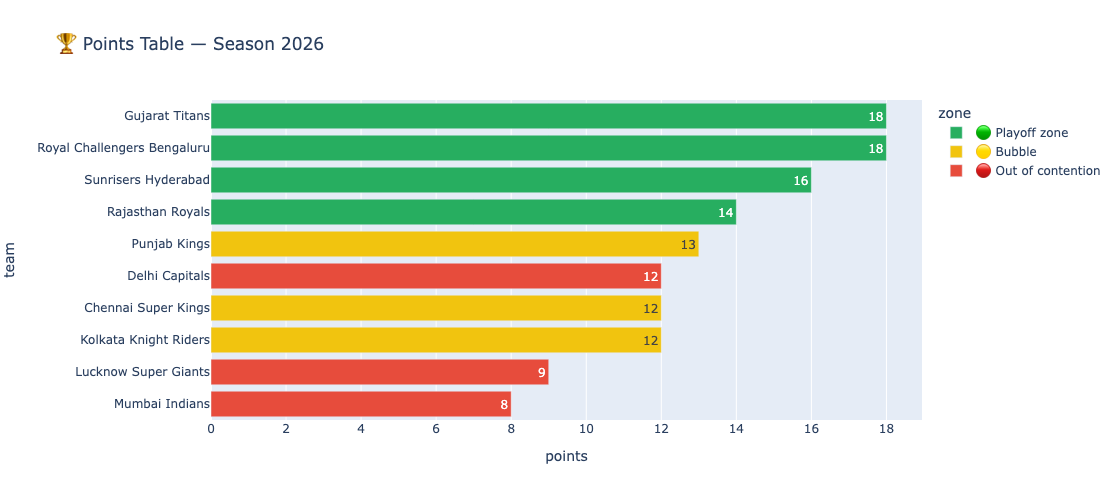

In [4]:
# Visual points table - color top 4 differently
tbl = points_table.copy()
tbl['zone'] = np.where(tbl['position'] <= 4, '🟢 Playoff zone',
              np.where(tbl['position'] <= 7, '🟡 Bubble', '🔴 Out of contention'))

fig = px.bar(
    tbl,
    x='points', y='team', orientation='h',
    color='zone',
    color_discrete_map={'🟢 Playoff zone': '#27ae60',
                        '🟡 Bubble':       '#f1c40f',
                        '🔴 Out of contention': '#e74c3c'},
    text='points',
    hover_data={'won': True, 'lost': True, 'nrr': ':.3f', 'played': True},
    title=f'🏆 Points Table — Season {CURRENT_SEASON}'
)
fig.update_layout(height=500, yaxis={'categoryorder': 'total ascending'})
fig.show()

## 3. Identify Remaining Matches

**Problem:** Cricsheet only has *played* matches. We don't have the official fixture list for unfinished matches.

**Solution:** Estimate the remaining matches by assuming each team plays a standard IPL schedule of ~14 league games (2 against each of 7 other teams in a 10-team format with home-and-away).

Then we'll construct the **remaining fixtures as all pairs of teams who haven't played their expected number of matches against each other yet.**

In [5]:
# Standard IPL: each team plays 14 league matches (10-team format: 7 opponents x 2)
GAMES_PER_TEAM = 14

current_matches = matches[matches['season_year'] == CURRENT_SEASON].dropna(subset=['team1', 'team2']).copy()
teams_this_season = sorted(pd.unique(current_matches[['team1', 'team2']].values.ravel()))

# Count actual played games between every pair
played_pairs = {}
for _, m in current_matches.iterrows():
    key = tuple(sorted([m['team1'], m['team2']]))
    played_pairs[key] = played_pairs.get(key, 0) + 1

# Expected matchups: 2 per pair in standard format
EXPECTED_PER_PAIR = 2
remaining_fixtures = []
for i, a in enumerate(teams_this_season):
    for b in teams_this_season[i+1:]:
        key = tuple(sorted([a, b]))
        played = played_pairs.get(key, 0)
        for _ in range(max(0, EXPECTED_PER_PAIR - played)):
            remaining_fixtures.append({'team1': a, 'team2': b})

remaining_df = pd.DataFrame(remaining_fixtures)
print(f'Teams this season: {len(teams_this_season)}')
print(f'Matches played:    {len(current_matches)}')
print(f'Matches remaining (estimated): {len(remaining_df)}')
if len(remaining_df):
    print('\nSample remaining fixtures:')
    print(remaining_df.head(10).to_string(index=False))

Teams this season: 10
Matches played:    66
Matches remaining (estimated): 24

Sample remaining fixtures:
              team1                       team2
Chennai Super Kings       Kolkata Knight Riders
Chennai Super Kings                Punjab Kings
Chennai Super Kings            Rajasthan Royals
Chennai Super Kings Royal Challengers Bengaluru
     Delhi Capitals              Gujarat Titans
     Delhi Capitals       Kolkata Knight Riders
     Delhi Capitals        Lucknow Super Giants
     Delhi Capitals              Mumbai Indians
     Delhi Capitals         Sunrisers Hyderabad
     Gujarat Titans        Lucknow Super Giants


## 4. Estimate Win Probability for Each Remaining Match

For each upcoming `team1 vs team2`, we blend three signals:

1. **Historical head-to-head** — how often team1 beats team2 across all IPL seasons (weighted 30%)
2. **Recent form** — each team's win rate in their last 10 matches this season (weighted 50%)
3. **NRR strength** — a small NRR-based adjustment (weighted 20%)

If we have no head-to-head data, we fall back to current-season win rate.

In [6]:
# Pre-compute helpers
h2h_all_seasons = matches.dropna(subset=['team1', 'team2', 'winner']).copy()

def head_to_head(team_a, team_b):
    games = h2h_all_seasons[
        ((h2h_all_seasons['team1'] == team_a) & (h2h_all_seasons['team2'] == team_b)) |
        ((h2h_all_seasons['team1'] == team_b) & (h2h_all_seasons['team2'] == team_a))
    ]
    if len(games) == 0:
        return None, 0
    a_wins = (games['winner'] == team_a).sum()
    return a_wins / len(games), len(games)


def recent_form(team, last_n=10):
    season_games = current_matches[
        (current_matches['team1'] == team) | (current_matches['team2'] == team)
    ].sort_values('date').tail(last_n)
    if len(season_games) == 0:
        return 0.5, 0
    wins = (season_games['winner'] == team).sum()
    return wins / len(season_games), len(season_games)


def win_probability(team_a, team_b, points_tbl):
    '''Probability that team_a beats team_b in their next encounter.'''
    # Signal 1: historical head-to-head
    h2h_prob, h2h_n = head_to_head(team_a, team_b)
    
    # Signal 2: current-season recent form (last 10 games)
    a_form, _ = recent_form(team_a)
    b_form, _ = recent_form(team_b)
    # Convert to head-to-head form differential, centered on 0.5
    if a_form + b_form > 0:
        form_prob = a_form / (a_form + b_form)
    else:
        form_prob = 0.5
    
    # Signal 3: NRR-based strength differential
    try:
        a_nrr = points_tbl.loc[points_tbl['team'] == team_a, 'nrr'].iloc[0]
        b_nrr = points_tbl.loc[points_tbl['team'] == team_b, 'nrr'].iloc[0]
    except IndexError:
        a_nrr = b_nrr = 0
    nrr_diff = a_nrr - b_nrr
    # Logistic: NRR diff of +1 -> ~0.62 win prob
    nrr_prob = 1 / (1 + np.exp(-nrr_diff * 0.6))
    
    # Blend
    if h2h_prob is None or h2h_n < 3:
        # Not enough h2h data - use form and NRR only
        prob = 0.7 * form_prob + 0.3 * nrr_prob
    else:
        prob = 0.3 * h2h_prob + 0.5 * form_prob + 0.2 * nrr_prob
    
    return float(np.clip(prob, 0.05, 0.95))


# Sanity check: pick the top 2 teams and check
if len(points_table) >= 2:
    t1, t2 = points_table.iloc[0]['team'], points_table.iloc[1]['team']
    p = win_probability(t1, t2, points_table)
    print(f'Example: P({t1} beats {t2}) = {p:.1%}')

Example: P(Royal Challengers Bengaluru beats Gujarat Titans) = 51.9%


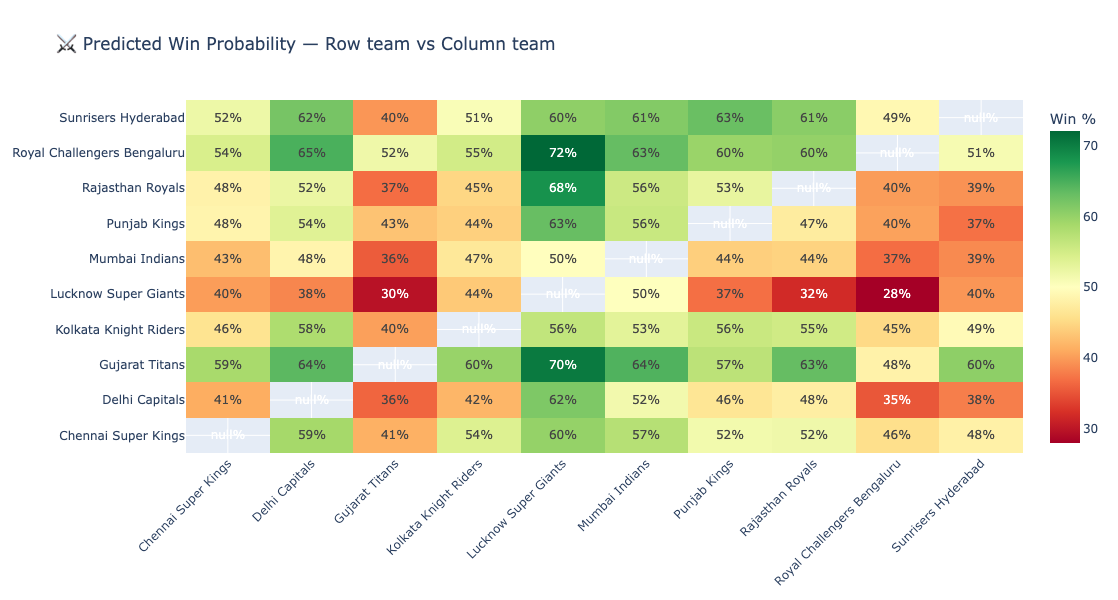

In [7]:
# Build a win-probability heatmap for visual context
wp_matrix = pd.DataFrame(np.nan, index=teams_this_season, columns=teams_this_season)
for a in teams_this_season:
    for b in teams_this_season:
        if a != b:
            wp_matrix.loc[a, b] = win_probability(a, b, points_table) * 100

fig = go.Figure(data=go.Heatmap(
    z=wp_matrix.values, x=wp_matrix.columns, y=wp_matrix.index,
    colorscale='RdYlGn', zmid=50,
    text=wp_matrix.values.round(0),
    texttemplate='%{text}%',
    hovertemplate='P(%{y} beats %{x}) = %{z:.1f}%<extra></extra>',
    colorbar=dict(title='Win %')
))
fig.update_layout(title='⚔️ Predicted Win Probability — Row team vs Column team',
                  height=600, xaxis={'tickangle': -45})
fig.show()

## 5. 🔒 Identify Locked & Eliminated Teams (Math First)

Before simulating, eliminate the obvious. For each team:

- **Max possible points** = current points + 2 × (remaining matches for that team)
- **Min possible points** = current points (assume they lose every remaining match)

A team is:
- 🟢 **LOCKED in top 4** if their *minimum* points > the *maximum* points of at least 6 other teams
- 🔴 **ELIMINATED** if their *maximum* points < the *minimum* points of at least 4 other teams
- 🟡 **IN THE RACE** otherwise

Only the in-the-race teams need Monte Carlo. Locked teams get 100%, eliminated teams get 0%.

In [9]:
# Count remaining matches per team
remaining_per_team = {t: 0 for t in teams_this_season}
for fx in remaining_fixtures:
    remaining_per_team[fx['team1']] += 1
    remaining_per_team[fx['team2']] += 1

# Compute max / min possible points for each team
team_bounds = []
for t in teams_this_season:
    cur = int(points_table.loc[points_table['team'] == t, 'points'].iloc[0])
    rem = remaining_per_team[t]
    team_bounds.append({
        'team': t,
        'current_points': cur,
        'remaining_matches': rem,
        'max_points': cur + 2 * rem,
        'min_points': cur,
    })
bounds = pd.DataFrame(team_bounds)

# Classify each team
def classify(row, bounds_df):
    others = bounds_df[bounds_df['team'] != row['team']]
    # LOCKED if at least 6 other teams can't catch this team's min points
    teams_below_us = (others['max_points'] < row['min_points']).sum()
    if teams_below_us >= 6:
        return 'LOCKED'
    # ELIMINATED if at least 4 other teams will always finish above us
    teams_above_us = (others['min_points'] > row['max_points']).sum()
    if teams_above_us >= 4:
        return 'ELIMINATED'
    return 'IN RACE'

bounds['status'] = bounds.apply(lambda r: classify(r, bounds), axis=1)
bounds = bounds.sort_values('current_points', ascending=False).reset_index(drop=True)

locked_teams     = bounds[bounds['status'] == 'LOCKED']['team'].tolist()
eliminated_teams = bounds[bounds['status'] == 'ELIMINATED']['team'].tolist()
in_race_teams    = bounds[bounds['status'] == 'IN RACE']['team'].tolist()

print('=' * 60)
print('📊 MATHEMATICAL STATUS CHECK')
print('=' * 60)
print(bounds.to_string(index=False))
print()
print(f'🟢 LOCKED in top 4:    {len(locked_teams)} team(s)  →  {locked_teams}')
print(f'🔴 ELIMINATED:         {len(eliminated_teams)} team(s)  →  {eliminated_teams}')
print(f'🟡 STILL IN THE RACE:  {len(in_race_teams)} team(s)  →  {in_race_teams}')
print()
print(f'Spots remaining to be decided: {4 - len(locked_teams)}')

📊 MATHEMATICAL STATUS CHECK
                       team  current_points  remaining_matches  max_points  min_points  status
             Gujarat Titans              18                  4          26          18 IN RACE
Royal Challengers Bengaluru              18                  5          28          18 IN RACE
        Sunrisers Hyderabad              16                  5          26          16 IN RACE
           Rajasthan Royals              14                  5          24          14 IN RACE
               Punjab Kings              13                  5          23          13 IN RACE
        Chennai Super Kings              12                  4          20          12 IN RACE
             Delhi Capitals              12                  5          22          12 IN RACE
      Kolkata Knight Riders              12                  5          22          12 IN RACE
       Lucknow Super Giants               9                  5          19           9 IN RACE
             Mumbai In

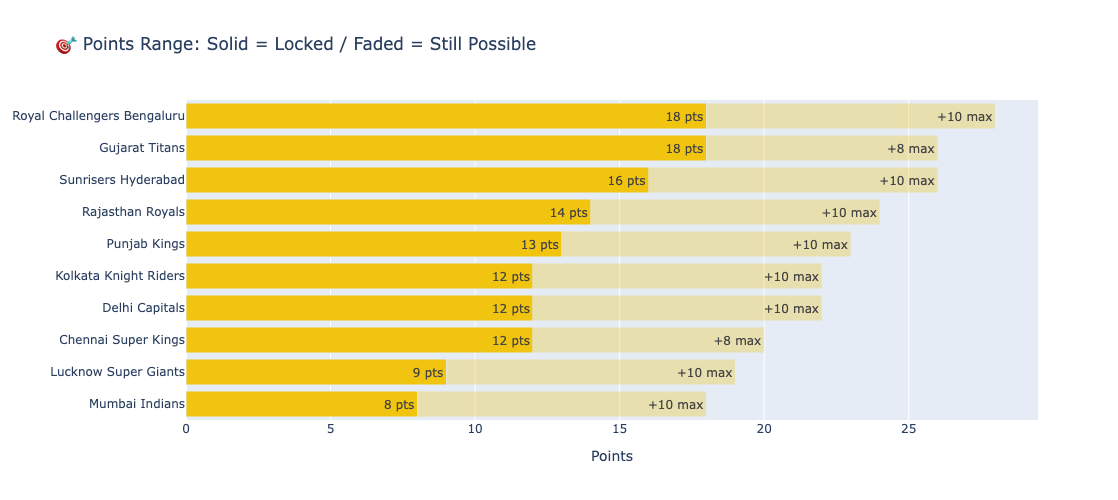

In [10]:
# Visualize the points range for each team (current → max possible)
fig = go.Figure()

status_colors = {'LOCKED': '#27ae60', 'IN RACE': '#f1c40f', 'ELIMINATED': '#e74c3c'}

for _, row in bounds.iterrows():
    color = status_colors[row['status']]
    # Bar: current points (solid)
    fig.add_trace(go.Bar(
        x=[row['current_points']], y=[row['team']],
        orientation='h', marker_color=color,
        name=row['status'], showlegend=False,
        text=f"{row['current_points']} pts",
        textposition='inside',
        hovertemplate=f"{row['team']}<br>Current: {row['current_points']}<br>Max possible: {row['max_points']}<br>Status: {row['status']}<extra></extra>"
    ))
    # Line extension: potential additional points
    if row['remaining_matches'] > 0:
        fig.add_trace(go.Bar(
            x=[row['max_points'] - row['current_points']], y=[row['team']],
            orientation='h', marker_color=color, marker_opacity=0.3,
            showlegend=False,
            text=f"+{row['max_points'] - row['current_points']} max",
            textposition='inside',
            hovertemplate=f"{row['team']}<br>Could still win up to {row['max_points'] - row['current_points']} more pts<extra></extra>"
        ))

fig.update_layout(
    barmode='stack',
    title='🎯 Points Range: Solid = Locked / Faded = Still Possible',
    xaxis_title='Points', height=500,
    yaxis={'categoryorder': 'array',
           'categoryarray': bounds.sort_values('current_points')['team'].tolist()}
)
fig.show()

## 6. 🎲 Focused Monte Carlo — Simulate ONLY the Race That Matters

Now we run the simulation **only on contested fixtures** — matches that involve at least one in-race team. Locked teams get 100%, eliminated teams get 0%, and we figure out how the remaining playoff spots get distributed among the in-race teams.

For locked-vs-eliminated or locked-vs-locked matches, the result barely matters for qualification, so we skip simulating their points (still need them for NRR if it ever matters).

In [ ]:
N_SIMS = 10000
rng = np.random.default_rng(RANDOM_STATE)

# Spots already taken by locked teams
spots_left = 4 - len(locked_teams)
print(f'Top 4 spots: {len(locked_teams)} locked, {spots_left} up for grabs')
print(f'Contested by: {in_race_teams}')
print(f'Eliminated:   {eliminated_teams} (auto-0%)')
print()

# Pre-compute win probs for ALL remaining fixtures (we'll skip non-impactful ones to save time)
fixture_probs = []
for fx in remaining_fixtures:
    a, b = fx['team1'], fx['team2']
    # Only matches where at least one in-race team plays affect the race
    impacts_race = (a in in_race_teams) or (b in in_race_teams)
    p = win_probability(a, b, points_table)
    fixture_probs.append((a, b, p, impacts_race))

impactful = sum(1 for *_, imp in fixture_probs if imp)
print(f'Remaining fixtures: {len(fixture_probs)} total, {impactful} impact the race')

# Run Monte Carlo only on in-race teams (locked teams = 100%, eliminated = 0%)
start_points = dict(zip(points_table['team'], points_table['points']))
start_nrr    = dict(zip(points_table['team'], points_table['nrr']))

top4_counts   = {t: 0 for t in teams_this_season}
winner_counts = {t: 0 for t in teams_this_season}

# Pre-lock locked teams
for t in locked_teams:
    top4_counts[t] = N_SIMS   # they're 100%

print(f'\nRunning {N_SIMS:,} simulations of the race...')

for sim in range(N_SIMS):
    pts = start_points.copy()
    for a, b, p_a_wins, impacts in fixture_probs:
        # We only NEED to simulate impactful matches, but simulating all keeps NRR/winner counts honest
        if rng.random() < p_a_wins:
            pts[a] += 2
        else:
            pts[b] += 2
    
    # Final ranking with NRR + tiny noise as tiebreaker
    final_ranking = sorted(
        pts.items(),
        key=lambda x: (x[1], start_nrr.get(x[0], 0) + rng.normal(0, 0.01)),
        reverse=True
    )
    
    # Tally - only for in-race teams (locked already at N, eliminated stay at 0)
    top4_set = {t for t, _ in final_ranking[:4]}
    for t in in_race_teams:
        if t in top4_set:
            top4_counts[t] += 1
    winner_counts[final_ranking[0][0]] += 1

print('Done.')

In [ ]:
# Qualification probabilities with status labels
def status_label(team):
    if team in locked_teams: return '🟢 LOCKED'
    if team in eliminated_teams: return '🔴 ELIMINATED'
    return '🟡 IN RACE'

qual = pd.DataFrame([
    {'team': t,
     'status': status_label(t),
     'current_position': int(points_table.loc[points_table['team'] == t, 'position'].iloc[0]),
     'current_points':   int(points_table.loc[points_table['team'] == t, 'points'].iloc[0]),
     'remaining':        remaining_per_team[t],
     'max_possible':     int(bounds.loc[bounds['team'] == t, 'max_points'].iloc[0]),
     'top4_pct':   top4_counts[t]  / N_SIMS * 100,
     'finish_1st_pct': winner_counts[t] / N_SIMS * 100}
    for t in teams_this_season
])
qual = qual.sort_values('top4_pct', ascending=False).reset_index(drop=True)
qual.index += 1
qual = qual.round(1)

print(f'🎯 Full qualification probabilities (after {N_SIMS:,} sims)\n')
print(qual.to_string())

## 7. 🫧 The Race: Who Grabs the Open Playoff Spot(s)?

Zoom in on the **in-race teams** — they're contesting the remaining spot(s). Locked teams are already through; eliminated teams are already out.

In [ ]:
# Focus on the contested teams only
race = qual[qual['status'] == '🟡 IN RACE'].copy()
race = race.sort_values('top4_pct', ascending=False).reset_index(drop=True)
race.index += 1

print(f'🫧 IN-RACE TEAMS — fighting for {spots_left} open spot(s)\n')
if len(race) == 0:
    print('   No teams in race — all 4 spots are mathematically decided!')
    print(f'   Top 4 (locked): {locked_teams}')
else:
    print(race[['team', 'current_position', 'current_points', 'remaining',
                'max_possible', 'top4_pct']].to_string())
    print()
    print('=' * 60)
    predicted_qualifiers = race.head(spots_left)['team'].tolist()
    if spots_left == 1:
        winner = race.iloc[0]
        print(f'  🏆 PREDICTED 4th QUALIFIER: {winner["team"]}')
        print(f'     (Top-4 probability: {winner["top4_pct"]:.1f}%)')
        if len(race) > 1:
            runner = race.iloc[1]
            print(f'     Closest rival: {runner["team"]} ({runner["top4_pct"]:.1f}%)')
            gap = winner['top4_pct'] - runner['top4_pct']
            print(f'     Gap: {gap:.1f} percentage points')
    else:
        print(f'  🏆 PREDICTED to fill {spots_left} open spot(s): {predicted_qualifiers}')
    print('=' * 60)

In [ ]:
# Plot in-race teams only
if len(race) > 0:
    fig = px.bar(
        race.reset_index(),
        x='top4_pct', y='team', orientation='h',
        text='top4_pct',
        color='top4_pct',
        color_continuous_scale='RdYlGn',
        range_color=[0, 100],
        hover_data={'current_position': True, 'current_points': True,
                    'remaining': True, 'max_possible': True},
        title=f'🫧 In-Race Teams — Probability of Grabbing One of {spots_left} Open Spot(s)',
        labels={'top4_pct': 'Top-4 Probability (%)'}
    )
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.update_layout(height=450, yaxis={'categoryorder': 'total ascending'},
                      xaxis_range=[0, 105], showlegend=False)
    fig.add_vline(x=50, line_dash='dash', line_color='grey',
                  annotation_text='50%', annotation_position='top')
    fig.show()
else:
    print('🟢 All 4 spots are mathematically locked — no race to plot!')

## 8. 📋 Full Picture — All 10 Teams

In [ ]:
fig = px.bar(
    qual,
    x='top4_pct', y='team', orientation='h',
    color='status',
    color_discrete_map={'🟢 LOCKED':     '#27ae60',
                        '🟡 IN RACE':    '#f1c40f',
                        '🔴 ELIMINATED': '#e74c3c'},
    text='top4_pct',
    hover_data={'current_position': True, 'current_points': True,
                'remaining': True, 'max_possible': True,
                'finish_1st_pct': ':.1f'},
    title=f'🎯 Playoff Qualification Probability — All Teams (Season {CURRENT_SEASON})'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=550, yaxis={'categoryorder': 'total ascending'},
                  xaxis_range=[0, 105])
fig.add_vline(x=50, line_dash='dash', line_color='grey')
fig.show()

## 9. 🏆 Final Verdict

In [ ]:
top4_pred = qual.head(4).reset_index(drop=True)
top4_pred.index += 1

print('=' * 70)
print(f'  🏆 PREDICTED TOP 4 — SEASON {CURRENT_SEASON} PLAYOFFS')
print('=' * 70)
for i, row in top4_pred.iterrows():
    if row['status'] == '🟢 LOCKED':
        tag = '✅ Mathematically locked'
    elif row['top4_pct'] > 85:
        tag = '✅ Near-certain'
    elif row['top4_pct'] > 60:
        tag = '⚠️  Likely'
    else:
        tag = '🎲 Toss-up'
    print(f'  {i}. {row["team"]:30s}  {row["top4_pct"]:5.1f}%   {tag}')
print('=' * 70)
print()
print(f'📊 SUMMARY')
print(f'   Locked teams (already in):   {len(locked_teams)}')
print(f'   In-race teams (contesting):  {len(in_race_teams)}')
print(f'   Eliminated teams:            {len(eliminated_teams)}')
print(f'   Open spots: {spots_left}')

if spots_left > 0 and len(in_race_teams) >= 2:
    print()
    sorted_race = qual[qual['status'] == '🟡 IN RACE'].sort_values('top4_pct', ascending=False)
    leader = sorted_race.iloc[0]
    runner = sorted_race.iloc[spots_left] if len(sorted_race) > spots_left else None
    print(f'🎯 LEADING the race: {leader["team"]} ({leader["top4_pct"]:.1f}%)')
    if runner is not None:
        print(f'   Closest miss-out:  {runner["team"]} ({runner["top4_pct"]:.1f}%)')
        gap = leader['top4_pct'] - runner['top4_pct']
        if gap < 10:
            print(f'   👀 Very close — gap is only {gap:.1f} pp. Final games will decide it.')

## Caveats & how to improve this

- **Estimated fixtures:** We don't have the official schedule from Cricsheet, so we assume each pair of teams plays exactly twice (standard IPL format). If a team already played some opponents twice in your data, we don't add a third match. If the real schedule differs, plug it in by replacing `remaining_df` directly.
- **Tiebreakers:** We approximate NRR tiebreakers using current-season NRR. The actual NRR would shift with each simulated result, but that effect is tiny relative to points differences and not worth the simulation cost.
- **Better win-prob model:** swap `win_probability()` for the trained chase-prediction model from `ipl_win_predictor.ipynb` — that gives ball-level granularity. For full match prediction, train a separate per-match model on `(team_a, team_b, venue, recent_form)` features.
- **Venue effects:** if you know remaining matches' venues, factor in home/away advantage — some venues have strong bat-first or chase patterns (see `ipl_eda_insights.ipynb` section 8).
- **Confidence intervals:** the 10,000 sims give you the data — `top4_counts[team] / N_SIMS ± 1.96 * sqrt(p(1-p)/N)` gives a 95% CI on each probability.